ДЗ 7. Фильмы dvdrental.
Кручинин С.В.


Telegraph Voyage 27 215.75 6.5 0.889 0
Zorro Ark 30 199.72 4.54 0.581 1
Wife Turn 28 198.73 4.79 0.677 3


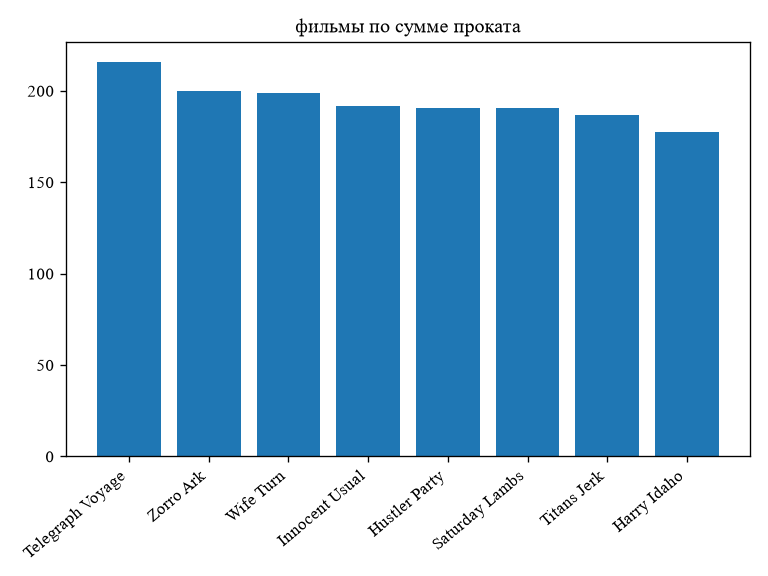

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

film = pd.read_csv('film.csv')
inv = pd.read_csv('inventory.csv')
rent = pd.read_csv('rental.csv')
pay = pd.read_csv('payment.csv')
rent['rental_date'] = pd.to_datetime(rent['rental_date'])
rent['return_date'] = pd.to_datetime(rent['return_date'])
t = film.merge(inv, on='film_id').merge(rent, on='inventory_id')
money = pay.groupby('rental_id', as_index=False)['amount'].sum()
t = t.merge(money, on='rental_id', how='left')
t['days'] = (t['return_date'] - t['rental_date']).dt.total_seconds() / 86400
due = t['rental_date'].dt.normalize() + pd.to_timedelta(t['rental_duration'], unit='D')
t['late'] = np.where(t['return_date'].isna(), np.nan, (t['return_date'].dt.normalize() > due).astype(float))
rpt = t.groupby(['film_id', 'customer_id']).size().reset_index(name='cnt')
rep = rpt[rpt['cnt'] > 1].groupby('film_id')['customer_id'].nunique()
g = t.groupby(['film_id', 'title'], as_index=False).agg(
    uniq=('customer_id', 'nunique'),
    dengi=('amount', 'sum'),
    sred=('days', 'mean'),
    dolya=('late', 'mean'),
)
g['povtor'] = g['film_id'].map(rep).fillna(0).astype(int)
g = g.sort_values('dengi', ascending=False)
for _, r in g.head(3).iterrows():
    print(r.title, int(r.uniq), round(r.dengi, 2), round(r.sred, 2), round(r.dolya, 3), int(r.povtor))

top = g.head(8)
plt.bar(top['title'], top['dengi'])
plt.xticks(rotation=40, ha='right')
plt.title('фильмы по сумме проката')
plt.tight_layout()
plt.savefig('dz07_bar.png', dpi=120)
